[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/04-unsupervised/02_umap_and_neighbor_embeddings.ipynb)

# Three Maps of the Same Data

**Session 16 · no homework grades this · the capstone often shows one of these**

PCA, t-SNE and UMAP all turn many dimensions into two, and they are not
interchangeable. This notebook runs all three on one dataset and asks the
questions that decide which one belongs in your report:

- what does each one **preserve**, and what does it discard?
- can it place a **new point** without refitting?
- how much does the picture change when the **seed** changes?
- is there a number, rather than an impression, that says how faithful it is?

`umap-learn` is in `requirements.txt`, so everything here runs in the course
environment. It is a post-class notebook because Quiz 2 takes a third of the
session.

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)   # umap's numba chatter

digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
X_train, X_new, y_train, y_new = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y)

print("umap-learn", umap.__version__)
print("train", X_train.shape, " held out", X_new.shape)

umap-learn 0.5.12
train (1347, 64)  held out (450, 64)


## 1. The three maps, side by side

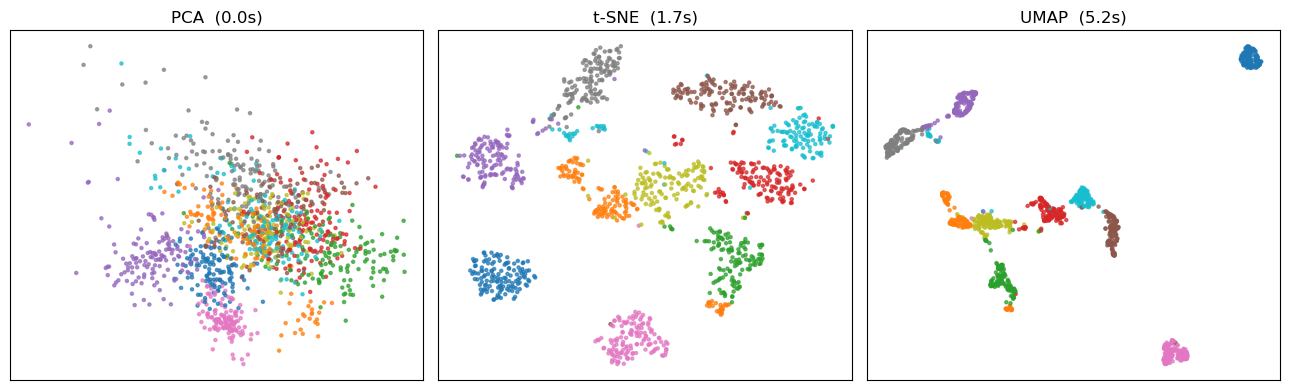

In [2]:
timings, embeddings = {}, {}

t0 = time.perf_counter()
pca = PCA(n_components=2, random_state=0).fit(X_train)
embeddings["PCA"] = pca.transform(X_train)
timings["PCA"] = time.perf_counter() - t0

t0 = time.perf_counter()
embeddings["t-SNE"] = TSNE(n_components=2, random_state=0, init="pca",
                           perplexity=30).fit_transform(X_train)
timings["t-SNE"] = time.perf_counter() - t0

t0 = time.perf_counter()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    random_state=0).fit(X_train)
embeddings["UMAP"] = reducer.embedding_
timings["UMAP"] = time.perf_counter() - t0

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, points) in zip(axes, embeddings.items()):
    ax.scatter(*points.T, c=y_train, cmap="tab10", s=5, alpha=.7)
    ax.set_title(f"{name}  ({timings[name]:.1f}s)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Trustworthiness: a number instead of an impression

Trustworthiness asks how many of each point's neighbours in the map were also
its neighbours in the original space. One means every neighbourhood survived;
values near 0.5 mean the map invented them.

In [3]:
print(f"{'method':<8} {'trustworthiness':>16} {'seconds':>9}")
for name, points in embeddings.items():
    score = trustworthiness(X_train, points, n_neighbors=15)
    print(f"{name:<8} {score:>16.4f} {timings[name]:>9.1f}")

method    trustworthiness   seconds
PCA                0.8125       0.0


t-SNE              0.9785       1.7
UMAP               0.9717       5.2


PCA preserves global geometry and loses local neighbourhoods; the neighbour
methods do the opposite. The number quantifies exactly that trade, and it
belongs in the caption of any embedding you publish.

## 3. Parameters change the picture, not the data

`n_neighbors` sets how much of the data each point's view includes — small
values chase local structure, large values approximate the global shape.
`min_dist` controls how tightly points may pack in the output.

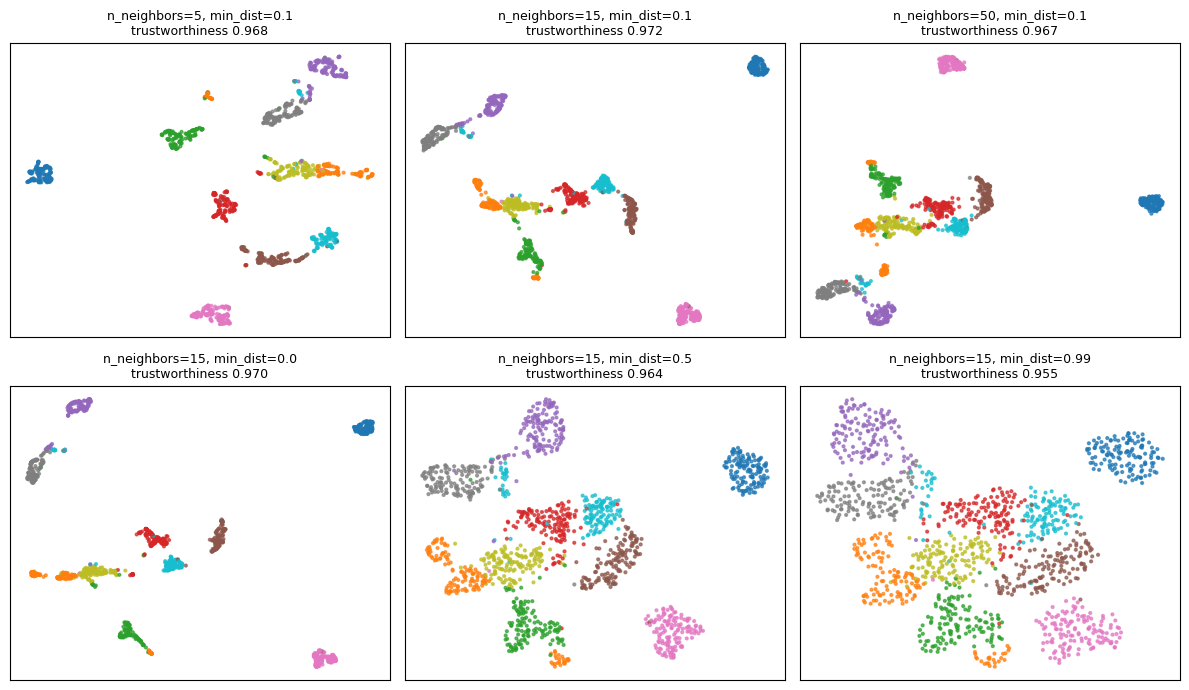

In [4]:
settings = [(5, 0.1), (15, 0.1), (50, 0.1), (15, 0.0), (15, 0.5), (15, 0.99)]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (k, d) in zip(axes.ravel(), settings):
    points = umap.UMAP(n_neighbors=k, min_dist=d, random_state=0).fit_transform(X_train)
    ax.scatter(*points.T, c=y_train, cmap="tab10", s=4, alpha=.7)
    ax.set_title(f"n_neighbors={k}, min_dist={d}\n"
                 f"trustworthiness {trustworthiness(X_train, points, n_neighbors=15):.3f}",
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Six pictures of one dataset, all honest. This is why an embedding without its
parameters is not a result: a reader cannot tell whether the clusters you are
pointing at are structure or settings.

## 4. The thing t-SNE cannot do

UMAP learns a mapping, so it can place points it never saw. t-SNE optimises
positions for the points it was given, and has no `transform` at all.

held-out points placed by the fitted UMAP: (450, 2)


t-SNE: AttributeError - 'TSNE' object has no attribute 'transform'


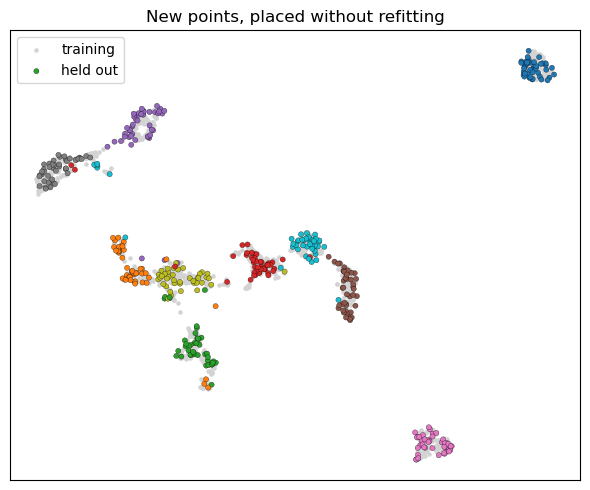

In [5]:
projected = reducer.transform(X_new)
print("held-out points placed by the fitted UMAP:", projected.shape)

try:
    TSNE(n_components=2).fit(X_train).transform(X_new)
except AttributeError as err:
    print("t-SNE:", type(err).__name__, "-", err)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(*reducer.embedding_.T, c="lightgrey", s=5, label="training")
sc = ax.scatter(*projected.T, c=y_new, cmap="tab10", s=14, edgecolor="k", linewidth=.2,
                label="held out")
ax.set_title("New points, placed without refitting")
ax.set_xticks([]); ax.set_yticks([]); ax.legend()
plt.tight_layout(); plt.show()

That property is what makes UMAP usable inside a pipeline: fit on the training
fold, transform the validation fold, no leakage. A t-SNE plot is a picture of one
dataset and stays one.

## 5. Does the picture survive a change of seed?

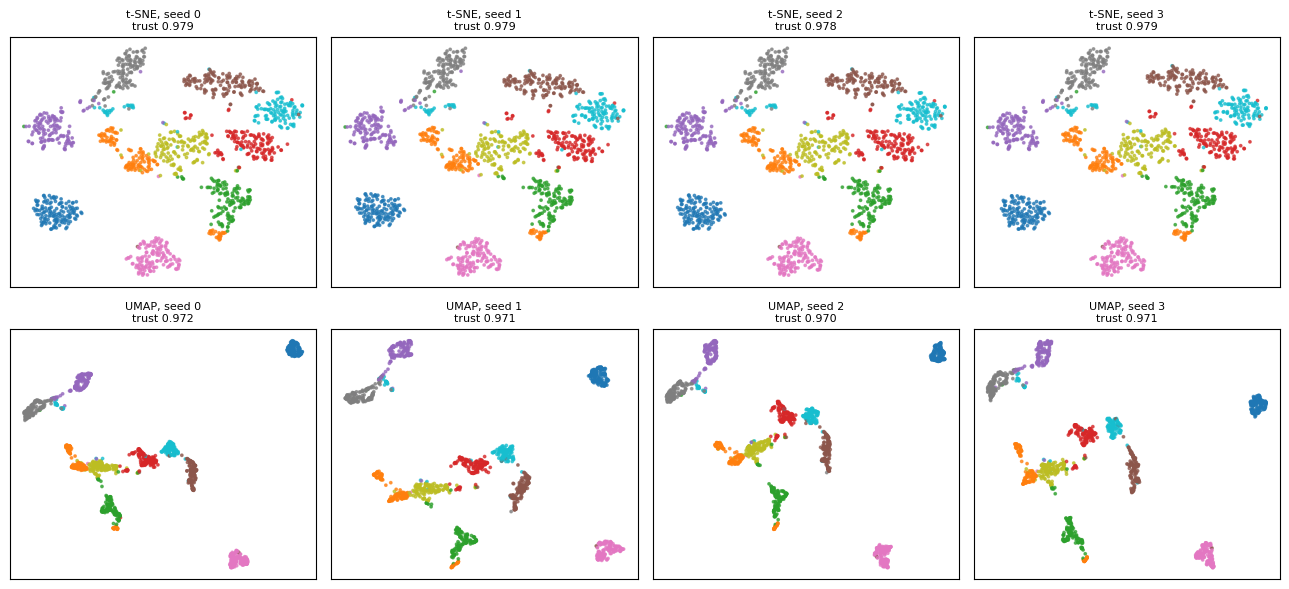

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for row, (name, factory) in enumerate([
        ("t-SNE", lambda s: TSNE(n_components=2, random_state=s, init="pca",
                                 perplexity=30).fit_transform(X_train)),
        ("UMAP", lambda s: umap.UMAP(n_neighbors=15, min_dist=0.1,
                                     random_state=s).fit_transform(X_train))]):
    for col, seed in enumerate(range(4)):
        points = factory(seed)
        ax = axes[row, col]
        ax.scatter(*points.T, c=y_train, cmap="tab10", s=3, alpha=.7)
        ax.set_title(f"{name}, seed {seed}\n"
                     f"trust {trustworthiness(X_train, points, n_neighbors=15):.3f}",
                     fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

The clusters are the same; where they sit on the page is not. Rotations,
reflections and rearrangements are free — the optimiser had no reason to prefer
one over another.

So: **the positions of the blobs, the distances between them, and their relative
sizes carry no meaning.** What carries meaning is which points ended up
together. Say the seed in the caption, and never build an argument on "cluster A
is closer to B than to C" in a t-SNE or UMAP plot.

## 6. PCA first — what it actually buys

The standard advice is to run PCA down to a few dozen components before a
neighbour method. Measure why.

In [7]:
rng = np.random.default_rng(16)
padded = np.hstack([X_train, rng.normal(size=(len(X_train), 900))])
print("with 900 noise features:", padded.shape)

t0 = time.perf_counter()
direct = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(padded)
direct_s = time.perf_counter() - t0

t0 = time.perf_counter()
reduced = PCA(n_components=20, random_state=0).fit_transform(padded)
staged = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(reduced)
staged_s = time.perf_counter() - t0

print(f"\n{'route':<28} {'trustworthiness':>16} {'seconds':>9}")
print(f"{'UMAP on all 964 features':<28} "
      f"{trustworthiness(padded, direct, n_neighbors=15):>16.4f} {direct_s:>9.1f}")
print(f"{'PCA to 20, then UMAP':<28} "
      f"{trustworthiness(padded, staged, n_neighbors=15):>16.4f} {staged_s:>9.1f}")

with 900 noise features: (1347, 964)



route                         trustworthiness   seconds
UMAP on all 964 features               0.6405       1.7


PCA to 20, then UMAP                   0.7124       1.6


The pre-step buys a cleaner neighbour graph: with nine hundred noise features
the distances that UMAP relies on are mostly noise, and PCA discards them before
they can mislead it. Any change in runtime is incidental — read the two numbers
above and say which effect dominated on this run.

## What to take from this

- PCA keeps global geometry; t-SNE and UMAP keep local neighbourhoods. Report
  trustworthiness rather than asserting that a map is faithful.
- An embedding without its parameters is not a result.
- UMAP can `transform` new points, so it can live in a pipeline. t-SNE cannot.
- Cluster positions, sizes and separations in a neighbour embedding are
  decoration. Say the seed; make claims only about co-membership.
- Reduce with PCA first when the dimension is large and noisy.

## Where to go next

- **Reading, Session 16** — the mechanics of both methods and how to choose.
- **`01_reading_unsupervised_results.ipynb`** — the multi-seed discipline applied
  to clustering as well.
- **The capstone** — if an embedding appears in your report, it needs the
  parameters, the seed, and a sentence about what it does not show.